# 12 — TCN Trading-Parameter Grid Search

**Memory-efficient design for M4 MacBook Pro:**
- Model inference runs **once** → `probs_test` cached in RAM (~1 MB)
- Each backtest combo is a pure Python loop: ~0.01–0.05 s, <1 MB per run
- Only scalar metrics are stored per combo (no equity arrays)
- Total peak overhead: <50 MB over baseline

**What we're searching:** The TCN model is frozen. AUC=0.60 confirmed real signal.
The -4.2% result in notebook 11 was caused by entering at `P≥0.40` thresholds — too low,
flooding entries with low-conviction bars that hit ATR stop-losses.
This search finds the threshold+risk combination that best extracts the latent signal.

In [1]:
# ── Grid ──────────────────────────────────────────────────────────────────────
GRID = {
    'long_threshold':  [0.44, 0.47, 0.50, 0.53, 0.56],
    'short_threshold': [0.44, 0.47, 0.50, 0.53, 0.56],
    'atr_multiplier':  [1.5, 2.0, 2.5, 3.0],
    'min_sl':          [0.010, 0.015, 0.020],
    'take_profit':     [0.025, 0.035, 0.045],
    'min_hold':        [4, 6, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}

# Exit thresholds derived from entry thresholds (saves 2 grid dimensions)
# EXIT_LONG  = max(0.28, long_threshold  - 0.10)
# EXIT_SHORT = max(0.28, short_threshold - 0.10)

MIN_TRADES      = 20      # skip combos with too few trades
OPTIMISE_METRIC = 'sharpe'  # 'sharpe' | 'calmar' | 'total_return' | 'win_rate' | 'profit_factor'

# ── Notebook 11 settings (must match) ────────────────────────────────────────
SYMBOL   = 'BTCUSDT'
INTERVAL = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'
SEQ_LEN   = 24
FRAC_D    = 0.4
FFD_THRES = 1e-4
TBM_VOL_WINDOW = 24
TBM_PT = 1.0
TBM_SL = 1.0
TBM_VERT_H = 12
AUX_FWD_H  = 6
TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL   = 3
TCN_DROPOUT  = 0.40
SEED = 42

In [14]:
import itertools
import json
import pickle
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import QuantileTransformer
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
torch.manual_seed(SEED)

if torch.cuda.is_available():         DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
                                       DEVICE = torch.device('mps')
else:                                  DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'; PURPLE='#AB47BC'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists(): REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'MODELS_DIR: {MODELS_DIR}')

Device: mps
MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models


## 1. Rebuild test probabilities (model inference — runs once)

Re-creates the exact same pipeline as notebook 11 to produce `probs_test`. 
No retraining — just loads the saved weights and runs a single forward pass.

In [3]:
# ── Paste TCN definition from notebook 11 (must stay in sync) ─────────────────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel - 1) * dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad))
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, :-self.pad] if self.pad > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch, out_ch, kernel, dilation), nn.ReLU(True), nn.Dropout(dropout),
            CausalConv1d(out_ch, out_ch, kernel, dilation), nn.ReLU(True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x) + res)

class TCNMultiTask(nn.Module):
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks, in_ch = [], input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch, ch, kernel, 2**i, dropout)); in_ch = ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(nn.LayerNorm(d), nn.Linear(d,32), nn.GELU(),
                                       nn.Dropout(dropout*.5), nn.Linear(32,3))
        self.head_vol = nn.Sequential(nn.LayerNorm(d), nn.Linear(d,16), nn.GELU(),
                                       nn.Linear(16,1), nn.Softplus())
    def forward(self, x):
        out  = self.tcn(x.transpose(1, 2))
        last = out[:, :, -1]
        return self.head_dir(last), self.head_vol(last).squeeze(-1)

In [4]:
# ── Rebuild features exactly as in notebook 11 ───────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    BACKTEST_COLS = json.load(f)['backtest_only_cols']

selected_features = pd.read_csv(MODELS_DIR / 'lgbm_features.csv', header=None)[0].tolist()

# FFD close
def _ffd_weights(d, thres=1e-4):
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] / k * (d - k + 1)
        if abs(w_k) < thres: break
        w.append(w_k); k += 1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    weights = _ffd_weights(d, thres)
    width   = len(weights)
    vals    = series.values.astype(np.float64)
    out     = np.full(len(vals), np.nan)
    for i in range(width - 1, len(vals)):
        out[i] = np.dot(weights, vals[i - width + 1 : i + 1])
    return pd.Series(out, index=series.index)

log_close      = np.log(feat_df['close'])
fracdiff_close = frac_diff_ffd(log_close, FRAC_D, FFD_THRES)
feat_df['fracdiff_close'] = fracdiff_close

# TBM labels (needed to define clean_df; not used in backtest)
log_rets    = log_close.diff()
rolling_vol = log_rets.rolling(TBM_VOL_WINDOW).std()
close_vals  = feat_df['close'].values; vol_vals = rolling_vol.values; n = len(close_vals)
tbm_labels  = np.full(n, np.nan)
for i in range(n - TBM_VERT_H):
    if np.isnan(vol_vals[i]) or vol_vals[i] <= 0: continue
    entry = close_vals[i]; upper = entry*(1+TBM_PT*vol_vals[i]); lower = entry*(1-TBM_SL*vol_vals[i])
    lbl = 2
    for j in range(1, TBM_VERT_H+1):
        px = close_vals[i+j]
        if px >= upper: lbl = 1; break
        elif px <= lower: lbl = 0; break
    tbm_labels[i] = lbl
feat_df['tbm_label'] = tbm_labels

# Aux + weights
fwd_vol = pd.concat([log_rets.shift(-h) for h in range(1, AUX_FWD_H+1)], axis=1).std(axis=1)
feat_df['fwd_vol'] = fwd_vol
w_raw = rolling_vol.fillna(rolling_vol.median()) / rolling_vol.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)

ALL_INPUT_FEATS = selected_features + ['fracdiff_close']
required_cols   = ALL_INPUT_FEATS + ['tbm_label','fwd_vol','sample_weight'] + BACKTEST_COLS
clean_df        = feat_df[required_cols].dropna()
_, _, test_df   = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)

# Load saved QuantileTransformer and transform test features
qt = pickle.loads((MODELS_DIR / 'tcn_qt.pkl').read_bytes())
X_test_raw = qt.transform(test_df[ALL_INPUT_FEATS].values).astype(np.float32)

# Build sequences
X_te = np.array([X_test_raw[i-SEQ_LEN:i] for i in range(SEQ_LEN, len(X_test_raw))], dtype=np.float32)

# Load model weights
model = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
model.load_state_dict(torch.load(MODELS_DIR / 'tcn_model.pt', map_location=DEVICE))
model.eval()

# Single forward pass — the ONLY inference call in this entire notebook
from torch.utils.data import DataLoader, TensorDataset
all_logits = []
with torch.no_grad():
    for xb in DataLoader(TensorDataset(torch.from_numpy(X_te)), batch_size=512):
        logits, _ = model(xb[0].to(DEVICE))
        all_logits.append(logits.cpu())

logits_test = torch.cat(all_logits).numpy()  # (N, 3)
probs_test  = torch.softmax(torch.from_numpy(logits_test), dim=1).numpy()
probs_down  = probs_test[:, 0].astype(np.float32)   # P(lower barrier)
probs_up    = probs_test[:, 1].astype(np.float32)   # P(upper barrier)

# Align test arrays
sig_index = test_df.index[SEQ_LEN:SEQ_LEN + len(probs_up)]
close_arr = test_df['close'].values[SEQ_LEN:SEQ_LEN + len(probs_up)].astype(np.float64)
atr_arr   = test_df['atr_14_pct'].values[SEQ_LEN:SEQ_LEN + len(probs_up)].astype(np.float64)

# Buy-and-hold baseline
bh_equity = close_arr / close_arr[0]

print(f'Test samples : {len(probs_up):,}')
print(f'P(up)  range : [{probs_up.min():.4f}, {probs_up.max():.4f}]')
print(f'P(down) range: [{probs_down.min():.4f}, {probs_down.max():.4f}]')
print(f'Memory used by probs_test: {probs_test.nbytes / 1e6:.2f} MB')

# Free model from GPU/MPS immediately — grid search only needs probs_test
model.cpu()
del model
if DEVICE.type == 'mps': torch.mps.empty_cache()
elif DEVICE.type == 'cuda': torch.cuda.empty_cache()
print('Model offloaded — grid search will use <50 MB RAM.')

Test samples : 13,212
P(up)  range : [0.0144, 0.6269]
P(down) range: [0.0143, 0.5702]
Memory used by probs_test: 0.16 MB
Model offloaded — grid search will use <50 MB RAM.


## 2. Backtest function

In [5]:
def run_backtest(p: dict) -> dict | None:
    """Run one backtest with parameter dict `p`. Returns metrics dict or None if too few trades."""
    lt  = p['long_threshold'];  st  = p['short_threshold']
    elt = max(0.28, lt - 0.10); est = max(0.28, st - 0.10)  # derived exit thresholds
    atr = p['atr_multiplier'];  msl = p['min_sl']
    tp  = p['take_profit']
    mnh = p['min_hold'];        mxh = p['max_hold']
    cd  = p['cooldown']

    cash = 1.0; units = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0; dynamic_sl = 0.0
    hold_count = 0; cooldown = 0

    equity = np.empty(len(close_arr), dtype=np.float64)
    n_long = n_short = n_sl = n_tp = n_conf = 0
    wins = 0; total_pnl = 0.0

    for i in range(len(close_arr)):
        px = close_arr[i]; p_up = probs_up[i]; p_dn = probs_down[i]

        if cooldown > 0: cooldown -= 1

        if in_pos:
            hold_count += 1
            pnl    = (px - entry_px)/entry_px if direction == 'long' \
                     else (entry_px - px)/entry_px
            reason = None
            if   pnl <= -dynamic_sl:                                         reason = 'sl'
            elif pnl >= tp:                                                   reason = 'tp'
            elif hold_count >= mxh:                                           reason = 'max_hold'
            elif hold_count >= mnh:
                if   direction == 'long'  and p_up < elt:                    reason = 'conf'
                elif direction == 'short' and p_dn < est:                    reason = 'conf'

            if reason:
                cash  = units * px if direction == 'long' else entry_cash * (1 + pnl)
                units = 0.0
                if reason == 'sl':   n_sl   += 1
                elif reason == 'tp': n_tp   += 1
                else:                n_conf += 1
                wins += int(pnl > 0); total_pnl += pnl
                in_pos = False; hold_count = 0; cooldown = cd

        if not in_pos and cooldown == 0:
            sl = max(atr * atr_arr[i], msl)
            if p_up >= lt:
                units = cash/px; cash = 0.0; in_pos = True; direction = 'long'
                entry_px = px; entry_cash = 0.0; hold_count = 0; dynamic_sl = sl; n_long += 1
            elif p_dn >= st and p_up < lt:
                entry_cash = cash; units = cash/px
                in_pos = True; direction = 'short'
                entry_px = px; hold_count = 0; dynamic_sl = sl; n_short += 1

        if in_pos and direction == 'long':
            equity[i] = units * px
        elif in_pos and direction == 'short':
            equity[i] = entry_cash * (1 + (entry_px - px)/entry_px)
        else:
            equity[i] = cash

    # Force-close
    if in_pos:
        px  = close_arr[-1]
        pnl = (px - entry_px)/entry_px if direction == 'long' else (entry_px - px)/entry_px
        cash = units*px if direction == 'long' else entry_cash*(1+pnl)
        wins += int(pnl > 0); total_pnl += pnl
        equity[-1] = cash

    n_trades = n_long + n_short
    if n_trades < MIN_TRADES: return None

    # Metrics
    eq = equity
    r  = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    sharpe = float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24*365)) if len(r) > 1 else 0.0
    pk     = np.maximum.accumulate(eq)
    dd_arr = (eq - pk) / (pk + 1e-12)
    max_dd = float(dd_arr.min())
    calmar = float((eq[-1] - 1) / (-max_dd + 1e-12)) if max_dd < 0 else 0.0
    win_rate   = wins / n_trades
    avg_pnl    = total_pnl / n_trades
    gross_win  = total_pnl / max(wins, 1)
    gross_loss = (total_pnl - wins * gross_win) / max(n_trades - wins, 1)
    profit_factor = abs(gross_win * wins / (gross_loss * (n_trades - wins) + 1e-12))

    return {
        **p,
        'n_trades': n_trades, 'n_long': n_long, 'n_short': n_short,
        'n_sl': n_sl, 'n_tp': n_tp, 'n_conf': n_conf,
        'total_return': float(eq[-1] - 1),
        'sharpe': sharpe, 'max_dd': max_dd, 'calmar': calmar,
        'win_rate': win_rate, 'avg_pnl': avg_pnl,
        'profit_factor': profit_factor,
        'alpha': float(eq[-1] - bh_equity[-1]),
    }

print('run_backtest() defined.')
print(f'BH return: {(bh_equity[-1]-1)*100:+.2f}%')

run_backtest() defined.
BH return: -1.02%


## 3. Build grid & run search

In [6]:
keys   = list(GRID.keys())
combos = list(itertools.product(*[GRID[k] for k in keys]))
print(f'Total combinations : {len(combos):,}')

# Rough timing estimate
import time
sample_p = dict(zip(keys, combos[0]))
t0 = time.perf_counter()
for _ in range(10): run_backtest(sample_p)
t_per = (time.perf_counter() - t0) / 10
print(f'~{t_per*1000:.1f} ms per backtest  →  ~{t_per*len(combos):.0f}s total  ({t_per*len(combos)/60:.1f} min)')

Total combinations : 10,800
~3.9 ms per backtest  →  ~43s total  (0.7 min)


In [7]:
results = []
for vals in tqdm(combos, desc='Grid search', ncols=80):
    p   = dict(zip(keys, vals))
    out = run_backtest(p)
    if out is not None:
        results.append(out)

results_df = pd.DataFrame(results)
print(f'\nValid combos (≥{MIN_TRADES} trades): {len(results_df):,} / {len(combos):,}')
if results_df.empty:
    print('No valid results — lower MIN_TRADES or widen the grid.')
else:
    print(f'Sharpe  range: [{results_df["sharpe"].min():.3f}, {results_df["sharpe"].max():.3f}]')
    print(f'Return  range: [{results_df["total_return"].min()*100:.1f}%, {results_df["total_return"].max()*100:.1f}%]')
    print(f'MaxDD   range: [{results_df["max_dd"].min()*100:.1f}%, {results_df["max_dd"].max()*100:.1f}%]')

Grid search: 100%|███████████████████████| 10800/10800 [00:38<00:00, 277.59it/s]


Valid combos (≥20 trades): 10,800 / 10,800
Sharpe  range: [-1.207, 1.809]
Return  range: [-41.9%, 102.8%]
MaxDD   range: [-53.5%, -9.6%]


## 4. Leaderboard — top 20

In [8]:
if results_df.empty:
    print('No results to display.')
else:
    top20 = results_df.sort_values(OPTIMISE_METRIC, ascending=False).head(20)
    display_cols = [
        'long_threshold','short_threshold','atr_multiplier','min_sl','take_profit',
        'min_hold','max_hold','cooldown',
        'n_trades','win_rate','total_return','sharpe','max_dd','calmar','profit_factor','alpha',
    ]
    fmt = {
        'win_rate':       '{:.1%}',
        'total_return':   '{:+.2%}',
        'sharpe':         '{:.3f}',
        'max_dd':         '{:.2%}',
        'calmar':         '{:.3f}',
        'profit_factor':  '{:.3f}',
        'alpha':          '{:+.2%}',
    }
    from IPython.display import display
    display(top20[display_cols].style.format(fmt))

,long_threshold,short_threshold,atr_multiplier,min_sl,take_profit,min_hold,max_hold,cooldown,n_trades,win_rate,total_return,sharpe,max_dd,calmar,profit_factor,alpha
3030,0.470000,0.500000,1.500000,0.010000,0.025000,6,48,2,324,53.1%,+96.31%,1.809,-15.10%,6.379,721918075926.725,+97.33%
3091,0.470000,0.500000,1.500000,0.015000,0.045000,6,48,3,285,56.5%,+99.74%,1.795,-16.04%,6.217,745172958905.486,+100.76%
4878,0.500000,0.470000,2.000000,0.010000,0.035000,6,48,2,313,53.0%,+102.83%,1.766,-18.66%,5.510,764393228371.462,+103.85%
3049,0.470000,0.500000,1.500000,0.010000,0.045000,4,24,3,323,56.3%,+87.87%,1.753,-15.36%,5.720,676598647506.588,+88.89%
3028,0.470000,0.500000,1.500000,0.010000,0.025000,6,24,2,340,52.9%,+90.49%,1.740,-15.00%,6.032,690797844261.045,+91.51%
3087,0.470000,0.500000,1.500000,0.015000,0.045000,4,48,3,293,59.4%,+91.49%,1.737,-16.66%,5.493,697836144878.531,+92.51%
3379,0.470000,0.500000,3.000000,0.010000,0.045000,6,48,3,277,57.0%,+95.82%,1.708,-17.90%,5.354,725021352446.772,+96.84%
3095,0.470000,0.500000,1.500000,0.015000,0.045000,8,48,3,275,57.1%,+94.62%,1.690,-18.24%,5.188,719977699028.190,+95.64%
3066,0.470000,0.500000,1.500000,0.015000,0.025000,6,48,2,303,57.1%,+90.15%,1.677,-15.76%,5.722,692590303108.302,+91.17%
4890,0.500000,0.470000,2.000000,0.010000,0.045000,6,48,2,306,52.6%,+96.35%,1.676,-18.66%,5.163,733815423641.361,+97.37%


## 5. Distribution of key metrics

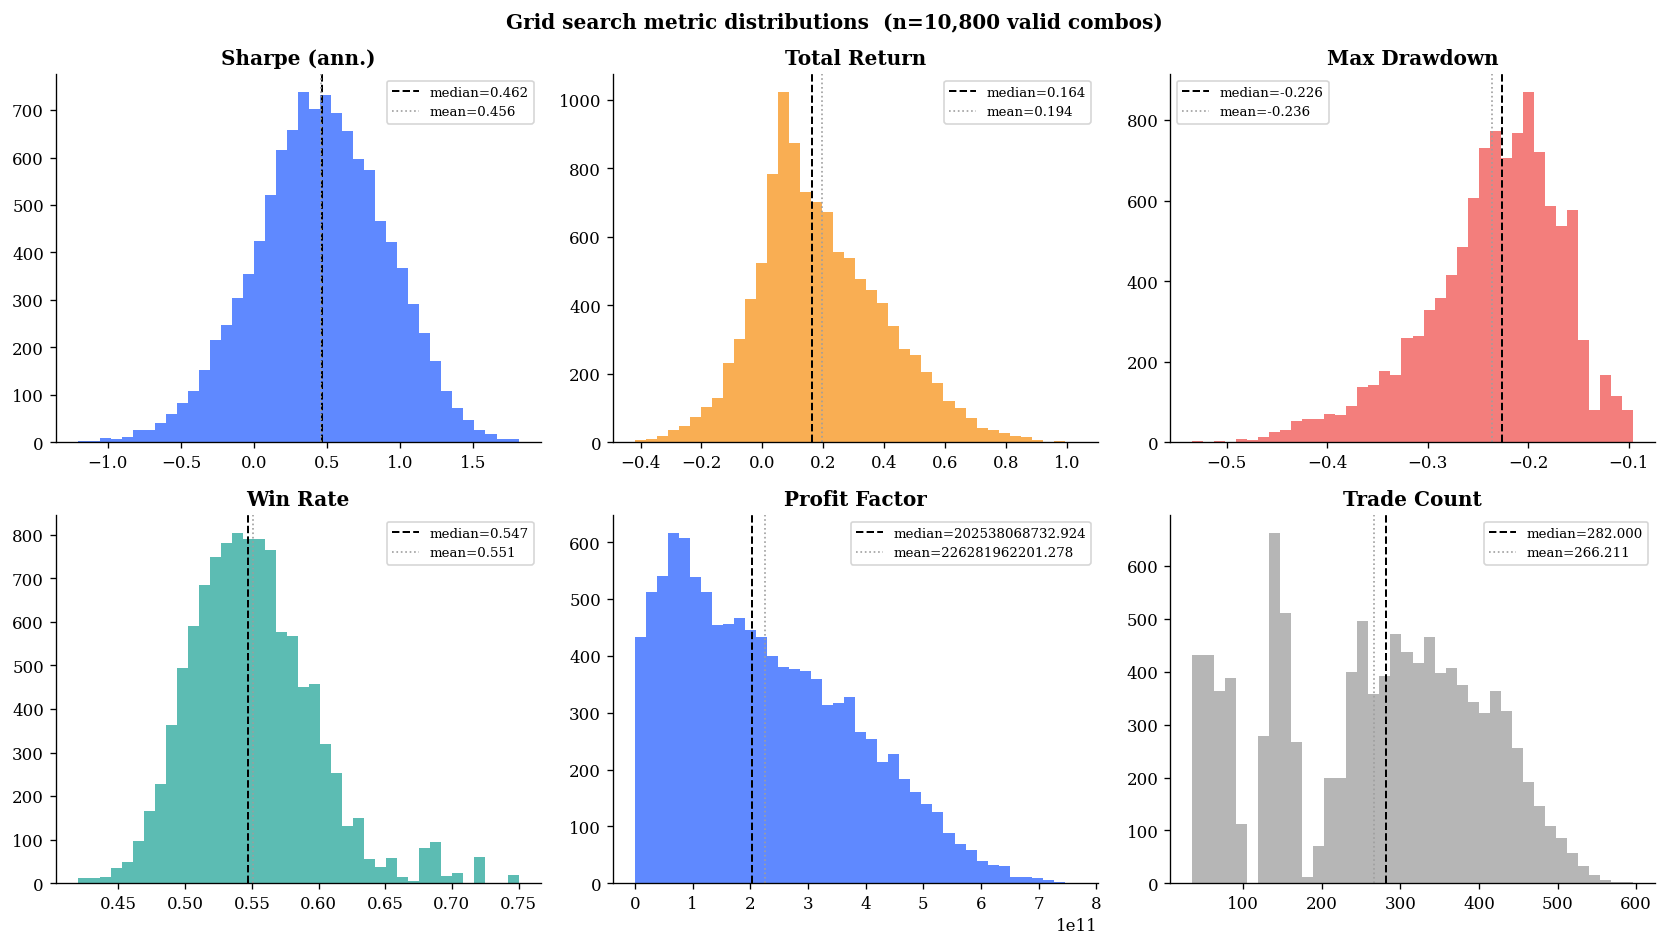

In [9]:
if not results_df.empty:
    metrics_to_plot = [
        ('sharpe',        'Sharpe (ann.)',    BLUE),
        ('total_return',  'Total Return',     ACCENT),
        ('max_dd',        'Max Drawdown',     RED),
        ('win_rate',      'Win Rate',         GREEN),
        ('profit_factor', 'Profit Factor',    BLUE),
        ('n_trades',      'Trade Count',      GREY),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, (col, label, color) in zip(axes.flat, metrics_to_plot):
        vals = results_df[col]
        ax.hist(vals, bins=40, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(vals.median(), color='black', ls='--', lw=1.2,
                   label=f'median={vals.median():.3f}')
        ax.axvline(vals.mean(), color=GREY, ls=':', lw=1,
                   label=f'mean={vals.mean():.3f}')
        ax.set_title(label, fontweight='bold'); ax.legend(fontsize=8)
    fig.suptitle(f'Grid search metric distributions  (n={len(results_df):,} valid combos)',
                 fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_distributions.png')
    plt.show()

## 6. Sensitivity analysis

Median Sharpe per individual parameter value — shows which levers matter most and in which direction.

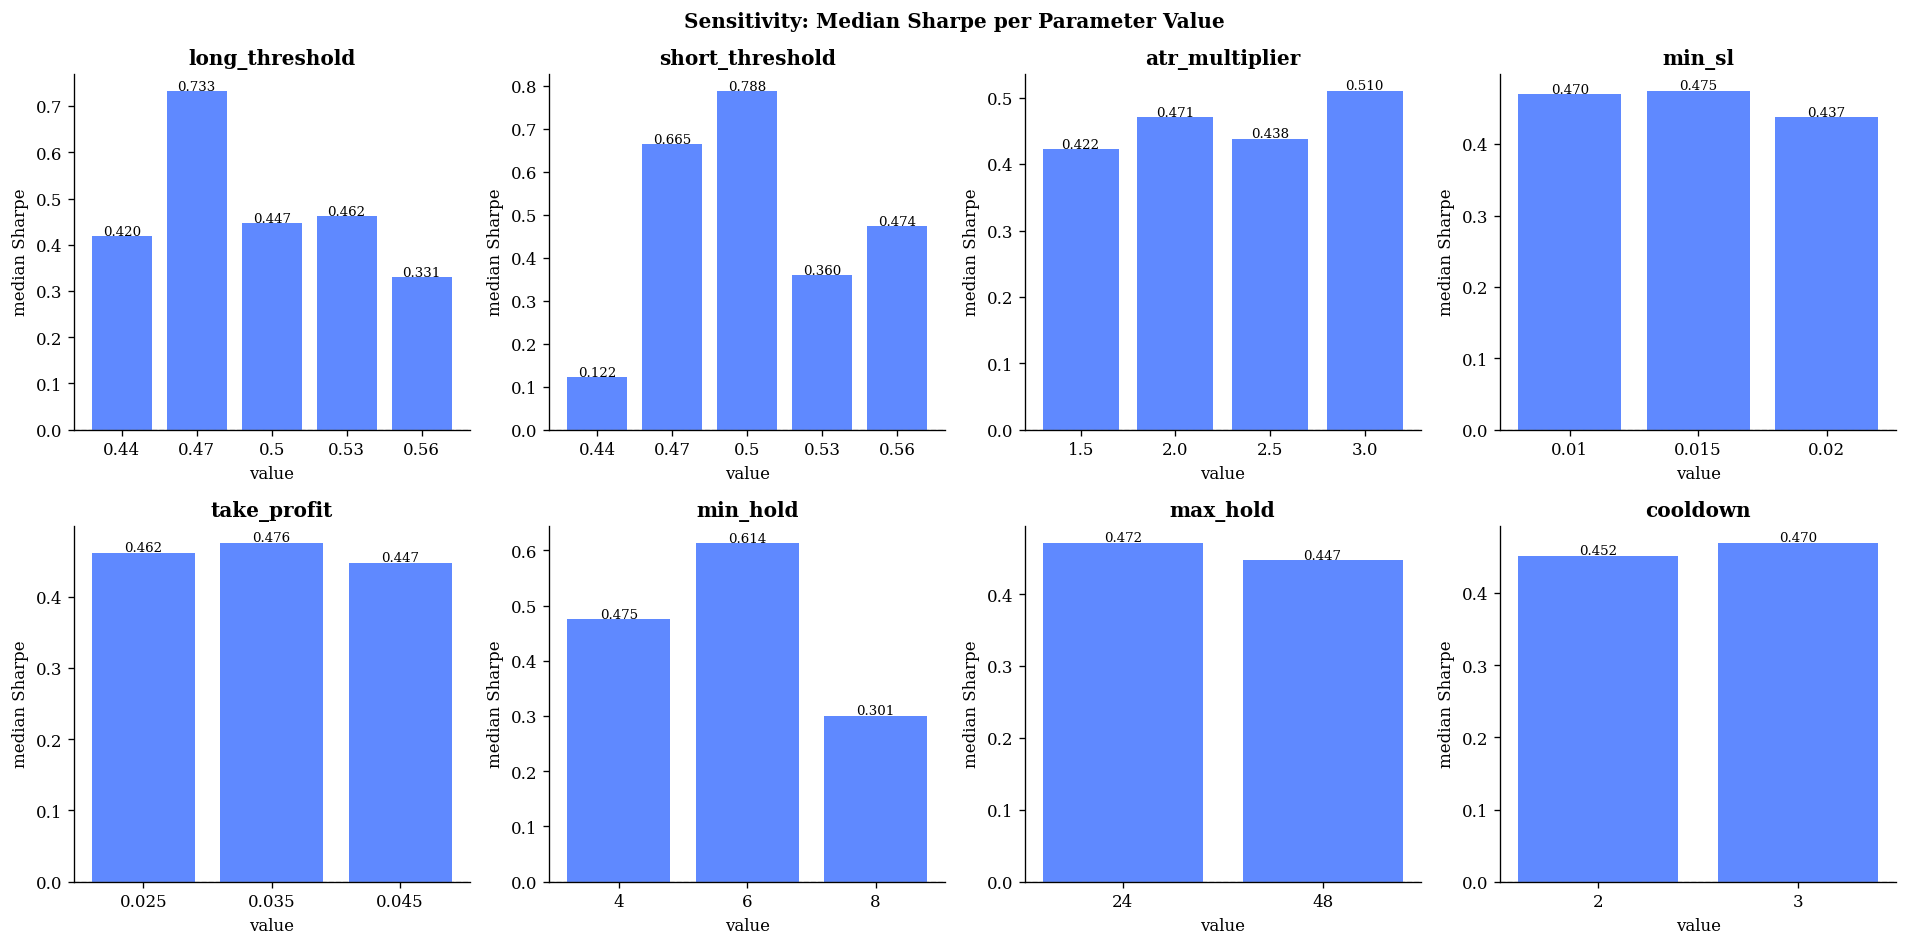

In [10]:
if not results_df.empty:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['sharpe'].median()
        ax.bar(grp.index.astype(str), grp.values, color=BLUE, alpha=0.75)
        ax.axhline(0, color=GREY, ls='--', lw=0.8)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('value'); ax.set_ylabel('median Sharpe')
        for i, (v, h) in enumerate(zip(grp.index.astype(str), grp.values)):
            ax.text(i, h + 0.002, f'{h:.3f}', ha='center', fontsize=8)
    fig.suptitle('Sensitivity: Median Sharpe per Parameter Value', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_sensitivity.png')
    plt.show()

## 7. Best configuration — equity curve & full summary

In [11]:
if results_df.empty:
    print('No results.')
else:
    best = results_df.sort_values(OPTIMISE_METRIC, ascending=False).iloc[0]
    best_p = {k: best[k] for k in keys}

    print('Best configuration:')
    for k, v in best_p.items():
        print(f'  {k:<20} = {v}')
    print(f'  exit_threshold_long  = {max(0.28, best_p["long_threshold"]-0.10):.2f}  (derived)')
    print(f'  exit_threshold_short = {max(0.28, best_p["short_threshold"]-0.10):.2f}  (derived)')
    print()

    # ── Re-run best to get equity array + trade log ───────────────────────────
    lt  = best_p['long_threshold'];  st  = best_p['short_threshold']
    elt = max(0.28, lt - 0.10);      est = max(0.28, st - 0.10)
    atr = best_p['atr_multiplier'];  msl = best_p['min_sl']
    tp  = best_p['take_profit']
    mnh = best_p['min_hold'];        mxh = best_p['max_hold']
    cd  = best_p['cooldown']

    cash = 1.0; units = 0.0; in_pos = False; direction = None
    entry_px = 0.0; entry_cash = 0.0; dynamic_sl = 0.0
    hold_count = 0; cooldown = 0
    equity_curve = [1.0]; trade_log = []

    for i, (ts, px, p_up, p_dn, atr_pct) in enumerate(
        zip(sig_index, close_arr, probs_up, probs_down, atr_arr)
    ):
        if cooldown > 0: cooldown -= 1
        if in_pos:
            hold_count += 1
            pnl    = (px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px
            reason = None
            if   pnl <= -dynamic_sl:                                      reason='sl'
            elif pnl >= tp:                                                reason='tp'
            elif hold_count >= mxh:                                        reason='max_hold'
            elif hold_count >= mnh:
                if   direction=='long'  and p_up < elt:                   reason='conf'
                elif direction=='short' and p_dn < est:                   reason='conf'
            if reason:
                cash = units*px if direction=='long' else entry_cash*(1+pnl)
                units = 0.0
                trade_log.append({'entry_time':entry_ts,'exit_time':ts,'direction':direction,
                                  'entry_px':entry_px,'exit_px':px,'pnl_pct':pnl,
                                  'reason':reason,'hold_h':hold_count,'dynamic_sl':dynamic_sl})
                in_pos=False; hold_count=0; cooldown=cd
        if not in_pos and cooldown==0:
            sl = max(atr*atr_arr[i], msl)
            if p_up >= lt:
                units=cash/px; cash=0.0; in_pos=True; direction='long'
                entry_px=px; entry_ts=ts; hold_count=0; dynamic_sl=sl
            elif p_dn >= st and p_up < lt:
                entry_cash=cash; units=cash/px; in_pos=True; direction='short'
                entry_px=px; entry_ts=ts; hold_count=0; dynamic_sl=sl
        if in_pos and direction=='long':         equity_curve.append(units*px)
        elif in_pos and direction=='short':      equity_curve.append(entry_cash*(1+(entry_px-px)/entry_px))
        else:                                    equity_curve.append(cash)

    if in_pos:
        px = close_arr[-1]; pnl=(px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px
        trade_log.append({'entry_time':entry_ts,'exit_time':sig_index[-1],'direction':direction,
                          'entry_px':entry_px,'exit_px':px,'pnl_pct':pnl,'reason':'eod',
                          'hold_h':hold_count,'dynamic_sl':dynamic_sl})
        equity_curve[-1] = entry_cash*(1+pnl) if direction=='short' else units*px

    equity_arr = np.array(equity_curve[1:])
    trades_df  = pd.DataFrame(trade_log)

    def sharpe(eq, ann=24*365):
        r = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
        return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(ann)) if len(r)>1 else 0.0
    def max_dd_fn(eq):
        pk = np.maximum.accumulate(eq)
        return float(((eq-pk)/(pk+1e-12)).min())

    pnl_s = trades_df['pnl_pct'] if not trades_df.empty else pd.Series(dtype=float)

    print('=' * 60)
    print(f'  BEST CONFIG SUMMARY  (optimised on: {OPTIMISE_METRIC})')
    print('=' * 60)
    print(f'  Total trades   : {len(trades_df)}')
    if not trades_df.empty:
        lt2  = trades_df[trades_df['direction']=='long']
        st2  = trades_df[trades_df['direction']=='short']
        print(f'    Long / Short : {len(lt2)} / {len(st2)}')
        print(f'  Win rate       : {(pnl_s>0).mean()*100:.1f}%')
        print('  Exit reasons:')
        for r_, g_ in trades_df.groupby('reason'):
            wr_ = (g_['pnl_pct']>0).mean()*100
            print(f'    {r_:<12}  n={len(g_):>3}  win={wr_:.1f}%  avg={g_["pnl_pct"].mean()*100:+.2f}%')
    print(f'  Total return   : {(equity_arr[-1]-1)*100:+.2f}%')
    print(f'  BH return      : {(bh_equity[-1]-1)*100:+.2f}%')
    print(f'  Alpha          : {(equity_arr[-1]-bh_equity[-1])*100:+.2f}pp')
    print(f'  Sharpe (ann.)  : {sharpe(equity_arr):.3f}')
    print(f'  Max drawdown   : {max_dd_fn(equity_arr)*100:.2f}%')
    print('=' * 60)

Best configuration:
  long_threshold       = 0.47
  short_threshold      = 0.5
  atr_multiplier       = 1.5
  min_sl               = 0.01
  take_profit          = 0.025
  min_hold             = 6.0
  max_hold             = 48.0
  cooldown             = 2.0
  exit_threshold_long  = 0.37  (derived)
  exit_threshold_short = 0.40  (derived)

  BEST CONFIG SUMMARY  (optimised on: sharpe)
  Total trades   : 324
    Long / Short : 229 / 95
  Win rate       : 53.1%
  Exit reasons:
    conf          n=163  win=77.9%  avg=+0.67%
    max_hold      n=  2  win=50.0%  avg=+0.34%
    sl            n=115  win=0.0%  avg=-1.54%
    tp            n= 44  win=100.0%  avg=+3.19%
  Total return   : +96.31%
  BH return      : -1.02%
  Alpha          : +97.33pp
  Sharpe (ann.)  : 1.809
  Max drawdown   : -15.10%


### Equity curve — best config

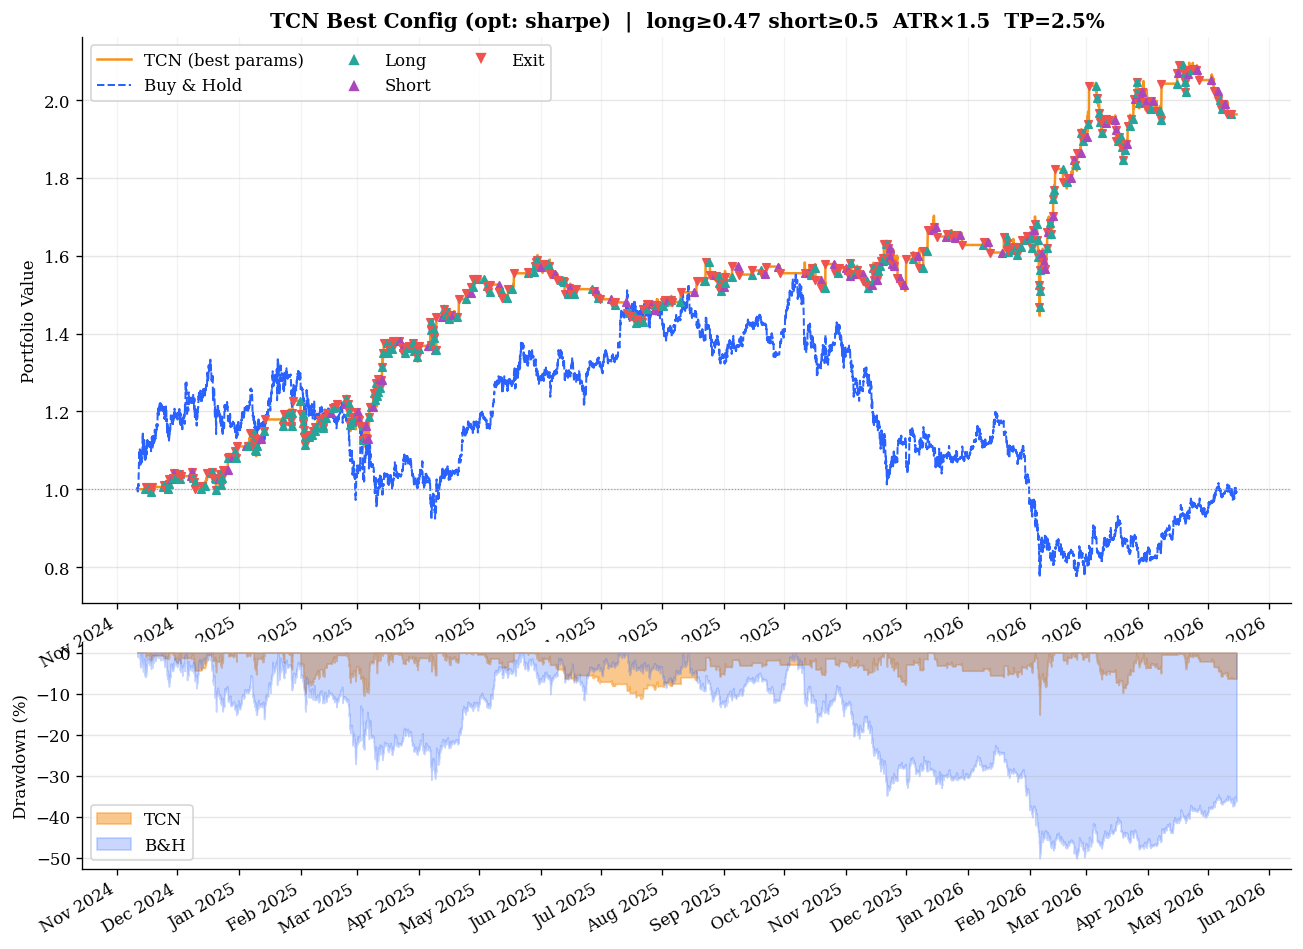

In [15]:
if not results_df.empty and not trades_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                             gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})

    ax = axes[0]
    ax.plot(sig_index, equity_arr, color=ACCENT, lw=1.5, label='TCN (best params)')
    ax.plot(sig_index, bh_equity,  color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
    eq_s = pd.Series(equity_arr, index=sig_index)
    for _, row in trades_df.iterrows():
        ei = eq_s.index.get_indexer([row['entry_time']], method='nearest')[0]
        xi = eq_s.index.get_indexer([row['exit_time']],  method='nearest')[0]
        col = GREEN if row['direction']=='long' else PURPLE
        ax.scatter(eq_s.index[ei], equity_arr[ei], marker='^', color=col, s=20, zorder=5)
        ax.scatter(eq_s.index[xi], equity_arr[xi], marker='v', color=RED,  s=20, zorder=5)
    from matplotlib.lines import Line2D
    ax.legend(handles=list(ax.get_legend_handles_labels()[0]) + [
        Line2D([0],[0],marker='^',color='w',markerfacecolor=GREEN, markersize=8,label='Long'),
        Line2D([0],[0],marker='^',color='w',markerfacecolor=PURPLE,markersize=8,label='Short'),
        Line2D([0],[0],marker='v',color='w',markerfacecolor=RED,   markersize=8,label='Exit'),
    ], ncol=3)
    ax.set_ylabel('Portfolio Value'); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)
    ax.set_title(f'TCN Best Config (opt: {OPTIMISE_METRIC})  |  '
                 f'long≥{best_p["long_threshold"]} short≥{best_p["short_threshold"]}  '
                 f'ATR×{best_p["atr_multiplier"]}  TP={best_p["take_profit"]*100:.1f}%',
                 fontweight='bold')

    ax = axes[1]
    pk_s = np.maximum.accumulate(equity_arr); pk_b = np.maximum.accumulate(bh_equity)
    ax.fill_between(sig_index, (equity_arr-pk_s)/(pk_s+1e-12)*100, 0,
                    color=ACCENT, alpha=0.5, label='TCN')
    ax.fill_between(sig_index, (bh_equity-pk_b)/(pk_b+1e-12)*100,  0,
                    color=BLUE,   alpha=0.25, label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    fig.savefig(FIGURES_DIR / 'tcn_grid_best_equity.png')
    plt.show()

## 8. Save results

In [16]:
if not results_df.empty:
    results_df.sort_values(OPTIMISE_METRIC, ascending=False).to_csv(
        MODELS_DIR / 'tcn_grid_results.csv', index=False
    )
    best_params_out = {
        **best_p,
        'exit_threshold_long':  round(max(0.28, best_p['long_threshold']  - 0.10), 2),
        'exit_threshold_short': round(max(0.28, best_p['short_threshold'] - 0.10), 2),
        'optimised_metric': OPTIMISE_METRIC,
        'sharpe':           round(float(best['sharpe']),        4),
        'total_return':     round(float(best['total_return']),  4),
        'max_dd':           round(float(best['max_dd']),        4),
        'n_trades':         int(best['n_trades']),
    }
    with open(MODELS_DIR / 'tcn_best_trading_params.json', 'w') as f:
        json.dump(best_params_out, f, indent=2)

    print(f'Saved: {MODELS_DIR}/tcn_grid_results.csv')
    print(f'Saved: {MODELS_DIR}/tcn_best_trading_params.json')
    print()
    print(json.dumps(best_params_out, indent=2))

Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_grid_results.csv
Saved: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/tcn_best_trading_params.json

{
  "long_threshold": 0.47,
  "short_threshold": 0.5,
  "atr_multiplier": 1.5,
  "min_sl": 0.01,
  "take_profit": 0.025,
  "min_hold": 6.0,
  "max_hold": 48.0,
  "cooldown": 2.0,
  "exit_threshold_long": 0.37,
  "exit_threshold_short": 0.4,
  "optimised_metric": "sharpe",
  "sharpe": 1.8088,
  "total_return": 0.9631,
  "max_dd": -0.151,
  "n_trades": 324
}
